# Pore Masks Notebook

This notebook detects pores in a magnetogram from a 24-hour magnetogram cube. The algorithm consists of the following steps:

1. Open the magnetogram cube and select one of the 1920 frames.
2. Select pixels with values above the 80th percentile, excluding the edges of the magnetogram by restricting the analysis to the region `[150:845]`.
3. Group neighboring pixels that satisfy these conditions into individual regions (pores).
4. Assign a circular mask to each detected region, with an area equivalent to that of the original region.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import sys
sys.path.append("../codes") # Add this folder to Python's module search path

from pore_detection import (
    load_magnetogram_frame,
    detect_magnetic_regions,
    filter_regions_by_radius
)
print(load_magnetogram_frame)
print(detect_magnetic_regions)
print(filter_regions_by_radius)

<function load_magnetogram_frame at 0x7f578771d760>
<function detect_magnetic_regions at 0x7f578771d8a0>
<function filter_regions_by_radius at 0x7f5787787920>


In [2]:
MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"

mag_frame, header = load_magnetogram_frame(
    MAG_cube,
    frame_number=0
)

regions, labeled_regions, mag_mask, threshold = detect_magnetic_regions(
    mag_frame,
    percentile=80,
    crop=(150, 845)
)

selected_regions = filter_regions_by_radius(
    regions,
    labeled_regions,
    mag_frame,
    min_radius=5
)

Magnetic threshold: 13.19
Number of detected regions: 25942
Maximum equivalent radius: 12.06 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 102


In [3]:
NFRAMES = 1920
N_REFERENCE_FRAMES = 4

magnetograms_of_reference = []

for n in range(N_REFERENCE_FRAMES):

    frame = n * NFRAMES // N_REFERENCE_FRAMES

    mag_frame, header = load_magnetogram_frame(
        MAG_cube,
        frame_number=frame
    )

    magnetogram_mean = np.nanmean(mag_frame)
    magnetogram_std = np.nanstd(mag_frame)

    magnetograms_of_reference.append({
        "frame": frame,
        "magnetogram": mag_frame,
        "header": header,
        "mean": magnetogram_mean,
        "std": magnetogram_std
    })

    print(
        f"Frame {frame:4d} | "
        f"Mean = {magnetogram_mean:.2f} G | "
        f"Std = {magnetogram_std:.2f} G"
    )

Frame    0 | Mean = -0.18 G | Std = 16.91 G
Frame  480 | Mean = -0.16 G | Std = 16.95 G
Frame  960 | Mean = -0.16 G | Std = 15.99 G
Frame 1440 | Mean = -0.26 G | Std = 15.75 G


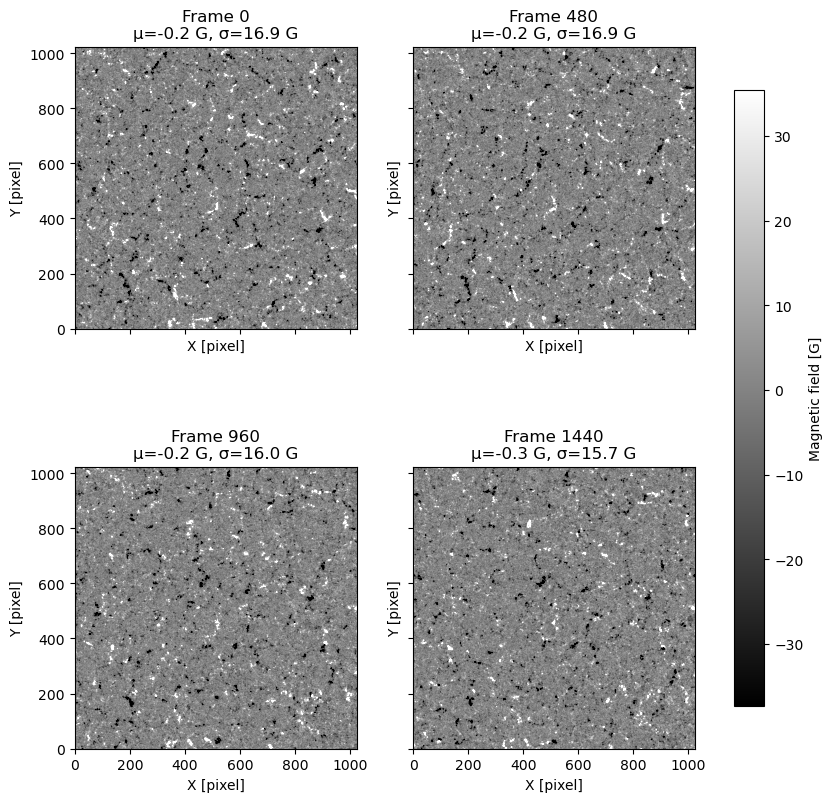

In [4]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    sharex=True,
    sharey=True
)

# Common color scale for all four magnetograms
all_values = np.concatenate([
    ref["magnetogram"][np.isfinite(ref["magnetogram"])].ravel()
    for ref in magnetograms_of_reference
])

vmin, vmax = np.percentile(all_values, [1, 99])

for ax, ref in zip(axes.flat, magnetograms_of_reference):

    im = ax.imshow(
        ref["magnetogram"],
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f'Frame {ref["frame"]}\n'
        f'μ={ref["mean"]:.1f} G, σ={ref["std"]:.1f} G'
    )

    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label="Magnetic field [G]",
    shrink=0.8
)

plt.show()

In [5]:
for ref in magnetograms_of_reference:

    # Get reference magnetogram
    mag_frame = ref["magnetogram"]

    # Detect magnetic regions
    regions, labeled_regions, mag_mask, threshold = detect_magnetic_regions(
        mag_frame,
        percentile=80,
        crop=(150, 845)
    )

    # Select regions according to equivalent radius
    selected_regions = filter_regions_by_radius(
        regions,
        labeled_regions,
        mag_frame,
        min_radius=5
    )

    # Store detection results

    # Properties of all detected connected magnetic regions
    ref["regions"] = regions

    # Labeled image assigning a unique integer ID to each connected magnetic region
    ref["labeled_regions"] = labeled_regions

    # Boolean mask identifying pixels that satisfy the magnetic-field criterion
    ref["mag_mask"] = mag_mask

    # Magnetic-field value corresponding to the selected percentile threshold
    ref["threshold"] = threshold

    # Regions that satisfy the minimum equivalent-radius criterion
    ref["selected_regions"] = selected_regions

Magnetic threshold: 13.19
Number of detected regions: 25942
Maximum equivalent radius: 12.06 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 102
Magnetic threshold: 13.29
Number of detected regions: 26349
Maximum equivalent radius: 13.27 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.62 pixels
Selected regions (r >= 5 px): 93
Magnetic threshold: 13.16
Number of detected regions: 26209
Maximum equivalent radius: 14.14 pixels
Mean equivalent radius: 0.87 pixels
Standard deviation: 0.63 pixels
Selected regions (r >= 5 px): 106
Magnetic threshold: 13.32
Number of detected regions: 26845
Maximum equivalent radius: 14.03 pixels
Mean equivalent radius: 0.86 pixels
Standard deviation: 0.61 pixels
Selected regions (r >= 5 px): 85


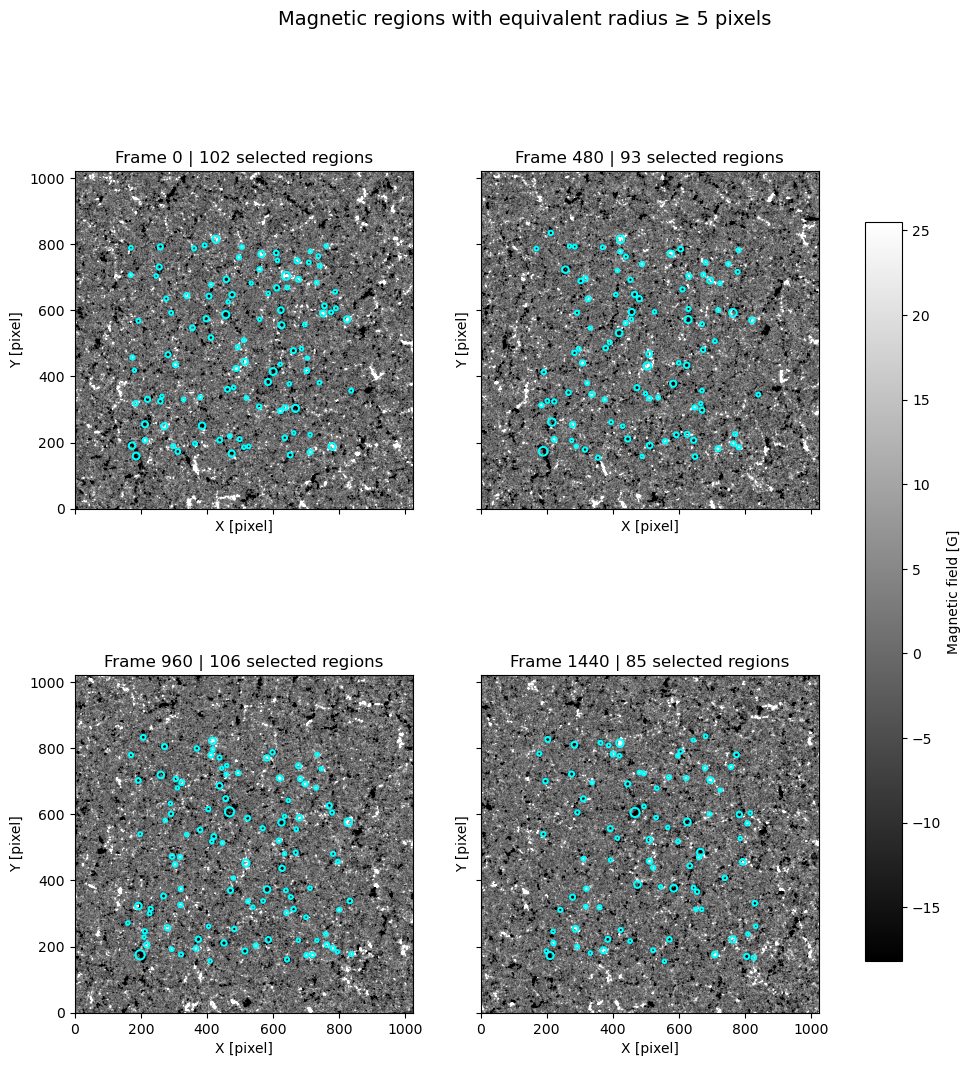

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# REFERENCE MAGNETOGRAMS + SELECTED MAGNETIC REGIONS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 12),
    sharex=True,
    sharey=True
)

# ------------------------------------------------------------
# Common color scale for all reference magnetograms
# ------------------------------------------------------------

all_values = np.concatenate([
    ref["magnetogram"][np.isfinite(ref["magnetogram"])].ravel()
    for ref in magnetograms_of_reference
])

vmin, vmax = np.percentile(all_values, [5, 98])

# ------------------------------------------------------------
# Plot each reference magnetogram
# ------------------------------------------------------------

for ax, ref in zip(axes.flat, magnetograms_of_reference):

    mag_frame = ref["magnetogram"]
    selected_regions = ref["selected_regions"]

    # Magnetogram
    im = ax.imshow(
        mag_frame,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    # Draw equivalent circles of the selected regions
    for region in selected_regions:

        circle = Circle(
            (region["x_center"], region["y_center"]),
            region["r_equivalent_pixels"],
            fill=False,
            linewidth=1.5,
            color="cyan"
        )

        ax.add_patch(circle)

    # Panel format
    ax.set_title(
        f'Frame {ref["frame"]} | '
        f'{len(selected_regions)} selected regions'
    )

    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

# ------------------------------------------------------------
# Common colorbar
# ------------------------------------------------------------

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    label="Magnetic field [G]",
    shrink=0.8
)

fig.suptitle(
    "Magnetic regions with equivalent radius ≥ 5 pixels",
    #f"Magnetic regions with equivalent radius ≥ {min_radius} pixels",
    fontsize=14
)

plt.show()


## Structure of `magnetograms_of_reference`

The `magnetograms_of_reference` variable is a **list of dictionaries**, where each dictionary contains the information associated with one reference magnetogram extracted from the 24-hour magnetic-field cube.

In the current analysis, four reference frames are selected (0, 480, 960, and 1440), corresponding to approximately six-hour intervals.

Each dictionary stores the original magnetogram, its statistical properties, the results of magnetic-region detection, and the regions selected according to the minimum equivalent-radius criterion.

### Dictionary structure

| Key | Data type | Description |
|---|---|---|
| `"frame"` | `int` | Temporal index of the magnetogram within the cube. |
| `"magnetogram"` | `np.ndarray` | 2D magnetic-field array. |
| `"header"` | `fits.Header` | General metadata from the FITS cube. |
| `"mean"` | `float` | Mean magnetic-field value over finite pixels. |
| `"std"` | `float` | Standard deviation of magnetic-field values over finite pixels. |
| `"regions"` | `list[dict]` | All detected connected magnetic regions, regardless of their size. |
| `"labeled_regions"` | `np.ndarray` | Integer-labeled array assigning a unique identifier to each connected region. |
| `"mag_mask"` | `np.ndarray` | Boolean mask identifying pixels that satisfy the magnetic-field threshold within the selected crop. |
| `"threshold"` | `float` | Magnetic-field magnitude threshold corresponding to the selected percentile (80th by default). |
| `"selected_regions"` | `list[dict]` | Regions satisfying the minimum equivalent-radius criterion, including their masks and magnetic-field statistics. |
| `"distance_matrix"` | `np.ndarray` | Pairwise centroid distances between selected regions in consecutive reference frames, if the tracking step has been executed. |

### Nested data structure

Each element of `magnetograms_of_reference` is a dictionary containing a separate list of selected regions:

```text
magnetograms_of_reference
│
├── [0] Frame 0
│   ├── magnetogram
│   ├── header
│   ├── mean, std
│   ├── regions
│   ├── labeled_regions
│   ├── mag_mask
│   ├── threshold
│   └── selected_regions
│       ├── [0] Pore candidate 1
│       ├── [1] Pore candidate 2
│       └── ...
│
├── [1] Frame 480
│   └── selected_regions [...]
│
├── [2] Frame 960
│   └── selected_regions [...]
│
└── [3] Frame 1440
    └── selected_regions [...]
```

**Important:** `regions` contains all detected magnetic regions, whereas `selected_regions` contains only those satisfying $r_{\mathrm{eq}} \geq r_{\min}$, with $r_{\min}=5$ pixels by default.

The index of a region in `selected_regions` is local to its corresponding frame. Therefore, regions with the same list index in different frames do not necessarily represent the same physical pore. Establishing these correspondences is the purpose of the pore-tracking algorithm.

The `"distance_matrix"` key is optional and is only available for frames where the pairwise-distance calculation has been performed.


# Tracking Pores Across Magnetogram Frames

Since some detected pores may persist across multiple frames of the magnetogram cube, although their positions and magnetic properties may change over time, we propose a basic algorithm to identify corresponding pores between consecutive frames, link their detections, and track their trajectories and magnetic-field evolution.

The algorithm consists of the following steps:

1. **Compute centroid distances:** Calculate the Euclidean distance between the centroids of detected regions in different frames.
2. **Identify matching pores:** Introduce a `"same_pores"` key to associate regions whose centroid separation satisfies the following threshold criterion:

   $$
   d_{\mathrm{centroid}} < d_{\mathrm{th}}, \qquad
   d_{\mathrm{th}} = \alpha r_{\mathrm{eq}} + \frac{\Delta \mathrm{frame}}{10}
   $$

3. **Update the pore position:** Define the updated pore center as the midpoint between the centroids of the matched regions.
4. **Update the equivalent radius:** Assign the average equivalent radius of the two matched regions.
5. **Visualize pore evolution:** Draw arrows representing the displacement vectors between matched regions, with arrow widths proportional to the change in mean magnetic-field strength.

# Pore tracking across reference magnetograms

To identify persistent magnetic regions, the selected pores are compared across consecutive reference magnetograms based on the spatial proximity of their centroids. The objective is to establish correspondences between detections at different times and reconstruct the temporal evolution of individual pores.

### 1. Pairwise distance calculation

For each pair of consecutive reference magnetograms, the centroid coordinates $(x,y)$ of all selected pores are extracted and stored in two NumPy arrays with shapes $((N,2))$ and $((M,2))$, where $(N)$ and $(M)$ are the numbers of selected pores in the previous and current frames, respectively.

The Euclidean distances between all possible pairs of centroids are computed using `scipy.spatial.distance.cdist`, producing a distance matrix $(D)$ with shape $((N,M))$:

$$
D_{ij}=\sqrt{(x_i-x_j)^2+(y_i-y_j)^2}
$$

Each element $(D_{ij})$ represents the distance, in pixels, between pore $i$ in the previous frame and pore $j$ in the current frame. Therefore, each row contains the distances from one pore in the previous frame to every selected pore in the current frame.

### 2. Candidate correspondence criterion

Not all pairs of regions are considered possible matches. A maximum displacement criterion is applied using the equivalent radius of each pore in the previous frame and the separation between the two reference frames:

$$
D_{ij}<\alpha r_{\mathrm{eq},i}+\frac{\Delta F}{100}
$$

where:

- $(r_{\mathrm{eq},i})$ is the equivalent radius of pore \($i$\), in pixels.
- ($\Delta F$) is the difference between the original frame indices.
- ($\alpha=2.06$) is the adopted scaling parameter.

This condition generates a Boolean matrix identifying valid candidate correspondences. The displacement threshold is evaluated separately for each pore in the previous frame.

### 3. One-to-one pore assignment

The valid candidate pairs are evaluated using `scipy.optimize.linear_sum_assignment`, which finds a minimum-cost assignment based on centroid distances. Dummy assignments allow pores to remain unmatched when no suitable correspondence is found.

Each accepted match connects a detection in the previous frame with a single detection in the current frame. This prevents multiple pores from being assigned to the same detection within a frame comparison.

### 4. Temporal tracking

A persistent `track_id` is assigned to each identified trajectory. When a correspondence is found, the new detection is appended to the existing track; otherwise, a new track is created.

Each detection retains its original frame index, region label, centroid coordinates, equivalent radius, area, and magnetic-field statistics computed over the detected region mask.

The resulting `pore_tracks` dictionary contains the observation history of each tracked pore, allowing its spatial displacement, size variation, and magnetic-field evolution to be examined across the reference magnetograms.

**Note:** Correspondences are established between consecutive elements of the reference-magnetogram list, which may be separated by multiple frames in the original data cube. Therefore, a persistent track represents a sequence of spatial associations at the sampled times, rather than proof of continuous detection between them.

In [7]:
from pore_tracking import track_pores, get_pore_properties
#Parameters----------
    #magnetograms_of_reference : sequence of dict
    #Reference magnetograms, in strictly increasing frame order.
    #alpha : float, optional Scaling factor for the previous pore's equivalent radius.
pore_tracks = track_pores(
    magnetograms_of_reference,
    alpha=2.06
)

Frames 0 → 480: 93 pores in current frame
Frames 480 → 960: 106 pores in current frame
Frames 960 → 1440: 85 pores in current frame


In [8]:
persistent_pores = {
    track_id: history
    for track_id, history in pore_tracks.items()
    if len(history) == N_REFERENCE_FRAMES
}

print("Persistent pores:", len(persistent_pores))

Persistent pores: 34


In [9]:
for track_id, history in persistent_pores.items():
    print(
        f"Track {track_id}: "
        f"frames = {[obs['frame'] for obs in history]}"
    )

Track 0: frames = [0, 480, 960, 1440]
Track 4: frames = [0, 480, 960, 1440]
Track 7: frames = [0, 480, 960, 1440]
Track 8: frames = [0, 480, 960, 1440]
Track 11: frames = [0, 480, 960, 1440]
Track 12: frames = [0, 480, 960, 1440]
Track 18: frames = [0, 480, 960, 1440]
Track 20: frames = [0, 480, 960, 1440]
Track 23: frames = [0, 480, 960, 1440]
Track 27: frames = [0, 480, 960, 1440]
Track 31: frames = [0, 480, 960, 1440]
Track 33: frames = [0, 480, 960, 1440]
Track 34: frames = [0, 480, 960, 1440]
Track 35: frames = [0, 480, 960, 1440]
Track 44: frames = [0, 480, 960, 1440]
Track 48: frames = [0, 480, 960, 1440]
Track 52: frames = [0, 480, 960, 1440]
Track 54: frames = [0, 480, 960, 1440]
Track 57: frames = [0, 480, 960, 1440]
Track 60: frames = [0, 480, 960, 1440]
Track 63: frames = [0, 480, 960, 1440]
Track 64: frames = [0, 480, 960, 1440]
Track 78: frames = [0, 480, 960, 1440]
Track 79: frames = [0, 480, 960, 1440]
Track 81: frames = [0, 480, 960, 1440]
Track 85: frames = [0, 480, 9

In [10]:
import importlib
import pore_tracking

importlib.reload(pore_tracking)

from pore_tracking import select_persistent_pores

sorted_persistent_pores = select_persistent_pores(
    pore_tracks,
    min_detections=N_REFERENCE_FRAMES
)

In [11]:
for pore in sorted_persistent_pores:
    print(
        f'Pore {pore["pore_id"]:02d} '
        f'(Track {pore["track_id"]}): '
        f'<B> = {pore["mean_magnetic_field"]:+.2f} G, '
        f'Detections = {len(pore["history"])}'
    )

Pore 01 (Track 60): <B> = -63.90 G, Detections = 4
Pore 02 (Track 35): <B> = -62.26 G, Detections = 4
Pore 03 (Track 81): <B> = +58.57 G, Detections = 4
Pore 04 (Track 11): <B> = +56.68 G, Detections = 4
Pore 05 (Track 57): <B> = +55.28 G, Detections = 4
Pore 06 (Track 0): <B> = -54.02 G, Detections = 4
Pore 07 (Track 27): <B> = -52.21 G, Detections = 4
Pore 08 (Track 12): <B> = -51.29 G, Detections = 4
Pore 09 (Track 101): <B> = +50.42 G, Detections = 4
Pore 10 (Track 93): <B> = +50.34 G, Detections = 4
Pore 11 (Track 54): <B> = -48.84 G, Detections = 4
Pore 12 (Track 4): <B> = -48.63 G, Detections = 4
Pore 13 (Track 23): <B> = +48.10 G, Detections = 4
Pore 14 (Track 33): <B> = -45.59 G, Detections = 4
Pore 15 (Track 63): <B> = -45.32 G, Detections = 4
Pore 16 (Track 98): <B> = -44.77 G, Detections = 4
Pore 17 (Track 18): <B> = +44.64 G, Detections = 4
Pore 18 (Track 52): <B> = -44.56 G, Detections = 4
Pore 19 (Track 31): <B> = -44.23 G, Detections = 4
Pore 20 (Track 79): <B> = -43.12

## Saving persistent pore properties for subsequent analysis

After identifying and ranking the persistent pores according to the absolute value of their time-averaged magnetic field, their spatial and magnetic properties are stored in a compressed NumPy archive (`.npz`).

The purpose of this step is to **preserve the complete detection history of each selected pore** in a compact and reusable format, avoiding the need to reload the original magnetogram cube or repeat the detection and tracking procedures for subsequent analyses.

The file `persistent_pore_tracks.npz` contains the pore identifiers, magnetic-field ranking information, and the properties measured at each reference frame. These data can subsequently be used to reconstruct centroid trajectories, examine variations in pore size and magnetic field, and generate plots describing their temporal evolution.

### Data organization

The selected sample contains **34 persistent pores**, each detected in all four reference magnetograms (frames 0, 480, 960, and 1440).

The stored properties are organized into one-dimensional arrays of shape `(34,)` for pore-level information and two-dimensional arrays of shape `(34, 4)` for properties measured at each detection.

For the two-dimensional arrays:

- **Rows** correspond to individual pores, ordered by decreasing absolute time-averaged magnetic field.
- **Columns** correspond to their successive detections in the reference magnetograms.

### Stored variables

| NPZ variable | Shape | Description |
|---|---|---|
| `pore_ids` | `(34,)` | Pore identifiers assigned according to the magnetic-field ranking, starting at 1. |
| `track_ids` | `(34,)` | Original persistent identifiers assigned by the tracking algorithm. |
| `mean_B` | `(34,)` | Signed time-averaged magnetic field of each pore, calculated from the mean field of its four detections. |
| `frames` | `(34, 4)` | Original magnetogram frame indices associated with each detection. |
| `x_centers` | `(34, 4)` | X coordinates of the pore centroids, in pixels. |
| `y_centers` | `(34, 4)` | Y coordinates of the pore centroids, in pixels. |
| `radii` | `(34, 4)` | Equivalent radii of the detected regions, in pixels. |
| `areas` | `(34, 4)` | Areas of the detected regions, in pixels squared. |
| `B_means` | `(34, 4)` | Signed mean magnetic field measured within each detected region, in gauss (G). |
| `B_stds` | `(34, 4)` | Spatial standard deviation of the magnetic field within each detected region, in gauss (G). |
| `labels` | `(34, 4)` | Original connected-component labels assigned to the regions in each magnetogram. |

### Magnetic-field ranking

The time-averaged magnetic field of each pore is calculated as the arithmetic mean of the magnetic-field means measured across its detections:

$$
\overline{B}_{\mathrm{pore}}=\frac{1}{N}\sum_{k=1}^{N}\langle B\rangle_k
$$

where \(N=4\) is the number of detections and \(\langle B\rangle_k\) is the spatially averaged magnetic field within the detected region at frame \(k\).

Pores are ranked in descending order of \(|\overline{B}_{\mathrm{pore}}|\), while the original sign of the magnetic field is preserved. Each detection contributes equally to the temporal average, regardless of its area.

### Data retrieval and interpretation

The archive can be loaded using `numpy.load()`. Individual pores can be selected using their `pore_ids`, while their original tracking identities remain available through `track_ids`.

For example, `x_centers[i, :]` and `y_centers[i, :]` contain the centroid coordinates of pore `i` across the four reference frames. Similarly, `radii[i, :]` and `B_means[i, :]` describe its size and magnetic-field evolution.

**Note:** The archive stores the measured properties of the selected regions, but not the original magnetograms or region masks. The `labels` array can be used to recover the corresponding region masks from the original labeled magnetograms, provided those data remain available.

The resulting trajectories describe associations between detections at the sampled reference times; they do not establish continuous pore evolution between observations.

In [12]:
import numpy as np
from pathlib import Path

# Output directory
output_dir = Path("../data/2018_08_25/pores")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "persistent_pore_tracks_4.npz"

# Extract pore identifiers and mean magnetic fields
pore_ids = np.array([
    pore["pore_id"] for pore in sorted_persistent_pores
])

track_ids = np.array([
    pore["track_id"] for pore in sorted_persistent_pores
])

mean_B = np.array([
    pore["mean_magnetic_field"] for pore in sorted_persistent_pores
])

# Extract temporal evolution for each pore
frames = np.array([
    [obs["frame"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

x_centers = np.array([
    [obs["x_center"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

y_centers = np.array([
    [obs["y_center"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

radii = np.array([
    [obs["r_equivalent_pixels"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

areas = np.array([
    [obs["area_pixels"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

B_means = np.array([
    [obs["mean_magnetic_field"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

B_stds = np.array([
    [obs["std_magnetic_field"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

labels = np.array([
    [obs["label"] for obs in pore["history"]]
    for pore in sorted_persistent_pores
])

# Map original frame numbers to reference magnetograms
reference_by_frame = {
    ref["frame"]: ref
    for ref in magnetograms_of_reference
}

# Recover the original region masks for each detection
masks = []
circle_masks = []

for pore in sorted_persistent_pores:
    pore_masks = []
    pore_circle_masks = []

    for obs in pore["history"]:
        ref = reference_by_frame[obs["frame"]]

        region = next(
            region for region in ref["selected_regions"]
            if region["label"] == obs["label"]
        )

        pore_masks.append(region["mask"])
        pore_circle_masks.append(region["circle_mask"])

    masks.append(pore_masks)
    circle_masks.append(pore_circle_masks)

masks = np.asarray(masks, dtype=bool)
circle_masks = np.asarray(circle_masks, dtype=bool)

# Save all properties and region masks
np.savez_compressed(
    output_file,
    pore_ids=pore_ids,
    track_ids=track_ids,
    mean_B=mean_B,
    frames=frames,
    x_centers=x_centers,
    y_centers=y_centers,
    radii=radii,
    areas=areas,
    B_means=B_means,
    B_stds=B_stds,
    labels=labels,
    masks=masks,
    circle_masks=circle_masks
)

print(f"Saved: {output_file}")
print(f"Region masks shape: {masks.shape}")
print(f"Circle masks shape: {circle_masks.shape}")

Saved: ../data/2018_08_25/pores/persistent_pore_tracks_4.npz
Region masks shape: (34, 4, 1024, 1024)
Circle masks shape: (34, 4, 1024, 1024)


In [13]:
data = np.load("../data/2018_08_25/pores/persistent_pore_tracks_4.npz")

pore_index = 0
frame_index = 1

print("Frame:", data["frames"][pore_index, frame_index])
print("Stored area:", data["areas"][pore_index, frame_index])
print("Mask area:", data["masks"][pore_index, frame_index].sum())

Frame: 480
Stored area: 274
Mask area: 274


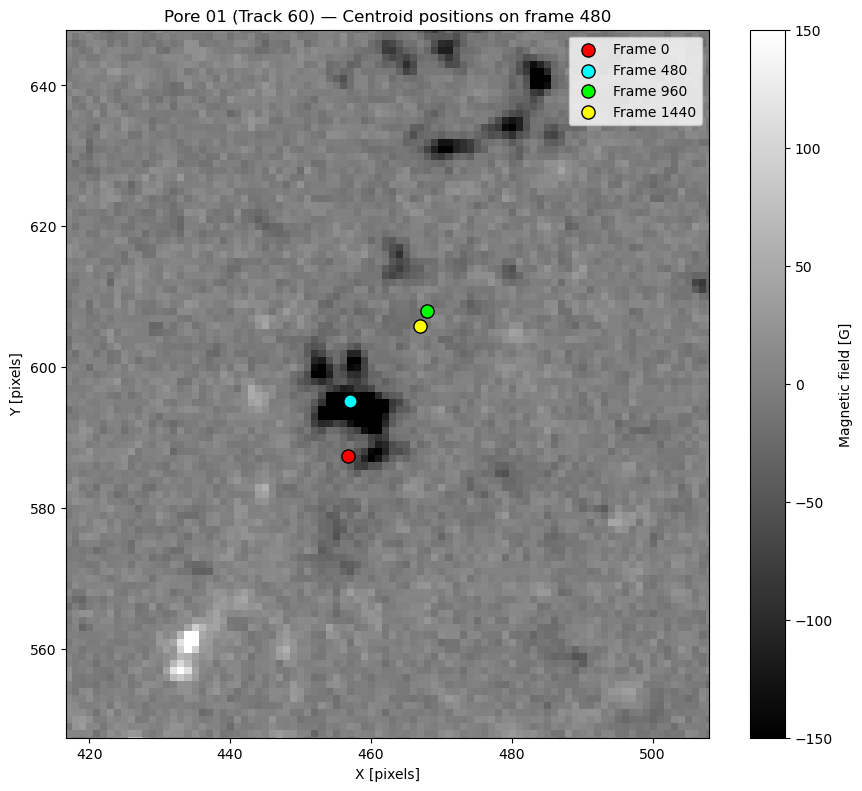

In [14]:
# Visual validation of pore centroid evolution across reference magnetograms.
# Load the saved persistent pore tracks and overlay the centroid positions
# measured at all four reference frames onto the second reference magnetogram.
# Each centroid is labeled by its corresponding frame to assess the spatial
# consistency of the pore tracking algorithm over time.

import numpy as np
import matplotlib.pyplot as plt

# Load persistent pore data
data = np.load("../data/2018_08_25/pores/persistent_pore_tracks_4.npz")

# Select the first pore in the magnetic-field ranking
pore_index = 0

frames = data["frames"][pore_index]
x_centers = data["x_centers"][pore_index]
y_centers = data["y_centers"][pore_index]

pore_id = data["pore_ids"][pore_index]
track_id = data["track_ids"][pore_index]

# Access the second reference magnetogram directly from the list
ref = magnetograms_of_reference[1]
mag_frame = ref["magnetogram"]

# Plot magnetogram
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=-150,
    vmax=150
)

# Plot all four centroid positions
colors = ["red", "cyan", "lime", "yellow"]

for frame, x, y, color in zip(frames, x_centers, y_centers, colors):
    ax.scatter(
        x, y,
        s=90,
        color=color,
        edgecolor="black",
        linewidth=1,
        label=f"Frame {frame}",
        zorder=3
    )

# Focus on the region around the centroid positions
margin = 40

ax.set_xlim(min(x_centers) - margin, max(x_centers) + margin)
ax.set_ylim(min(y_centers) - margin, max(y_centers) + margin)

ax.set_xlabel("X [pixels]")
ax.set_ylabel("Y [pixels]")
ax.set_title(
    f"Pore {pore_id:02d} (Track {track_id}) — "
    f"Centroid positions on frame {ref['frame']}"
)

ax.legend()
fig.colorbar(im, ax=ax, label="Magnetic field [G]")

plt.tight_layout()
plt.show()

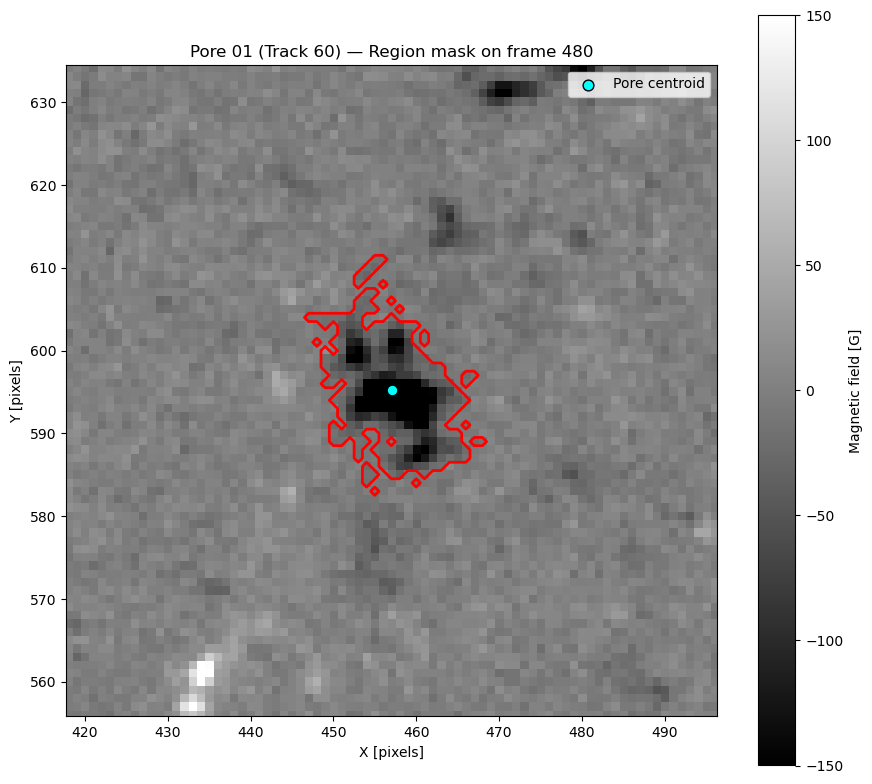

In [71]:
# Visual validation of pore morphology across reference magnetograms.
# Overlay the original detected region mask onto its corresponding
# reference magnetogram to verify the pore's position, size, and shape.
# Select the pore and reference frame directly through their list indices.

import numpy as np
import matplotlib.pyplot as plt

# Load persistent pore data
data = np.load("../data/2018_08_25/pores/persistent_pore_tracks_4.npz")

# Select pore and reference magnetogram
pore_index = 0
ref_index = 1

# Access the selected reference magnetogram
ref = magnetograms_of_reference[ref_index]
mag_frame = ref["magnetogram"]
frame = ref["frame"]

# Find the corresponding detection in the NPZ
detection_index = np.where(data["frames"][pore_index] == frame)[0][0]

# Retrieve pore properties and original region mask
pore_id = data["pore_ids"][pore_index]
track_id = data["track_ids"][pore_index]

x_center = data["x_centers"][pore_index, detection_index]
y_center = data["y_centers"][pore_index, detection_index]
radius = data["radii"][pore_index, detection_index]

region_mask = data["masks"][pore_index, detection_index]

# Plot magnetogram
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=-150,
    vmax=150
)

# Overlay the original pore boundary
ax.contour(
    region_mask,
    levels=[0.5],
    colors="red",
    linewidths=2
)

# Mark the pore centroid
ax.scatter(
    x_center,
    y_center,
    s=60,
    color="cyan",
    edgecolor="black",
    label="Pore centroid",
    zorder=3
)

# Focus on the selected pore
margin = 30

ax.set_xlim(x_center - radius - margin, x_center + radius + margin)
ax.set_ylim(y_center - radius - margin, y_center + radius + margin)

ax.set_xlabel("X [pixels]")
ax.set_ylabel("Y [pixels]")

ax.set_title(
    f"Pore {pore_id:02d} (Track {track_id}) — "
    f"Region mask on frame {frame}"
)

ax.legend()
fig.colorbar(im, ax=ax, label="Magnetic field [G]")

plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

ALPHA = 2.06

def get_pore_properties(ref, region):
    """
    Extract spatial and magnetic properties of a detected pore.
    Magnetic statistics are computed over its original region mask.
    """
    mag_frame = ref["magnetogram"]
    region_mask = region["mask"]

    values = mag_frame[region_mask & np.isfinite(mag_frame)]

    return {
        "frame": ref["frame"],
        "label": region["label"],
        "x_center": region["x_center"],
        "y_center": region["y_center"],
        "r_equivalent_pixels": region["r_equivalent_pixels"],
        "area_pixels": region["area_pixels"],
        "mean_magnetic_field": float(np.mean(values)) if values.size else np.nan,
        "std_magnetic_field": float(np.std(values)) if values.size else np.nan
    }


# ============================================================
# INITIALIZE TRACKS FROM THE FIRST REFERENCE FRAME
# ============================================================

pore_tracks = {}
next_track_id = 0

first_ref = magnetograms_of_reference[0]

# Map region indices to persistent track IDs
previous_track_ids = {}

for j, region in enumerate(first_ref["selected_regions"]):

    track_id = next_track_id
    next_track_id += 1

    pore_tracks[track_id] = [
        get_pore_properties(first_ref, region)
    ]

    previous_track_ids[j] = track_id


# ============================================================
# TRACK PORES ACROSS CONSECUTIVE REFERENCE FRAMES
# ============================================================

for i in range(len(magnetograms_of_reference) - 1):

    ref_previous = magnetograms_of_reference[i]
    ref_current = magnetograms_of_reference[i + 1]

    pores_previous = ref_previous["selected_regions"]
    pores_current = ref_current["selected_regions"]

    frame_difference = ref_current["frame"] - ref_previous["frame"]

    # Extract centroid coordinates
    centroids_previous = np.array([
        [r["x_center"], r["y_center"]]
        for r in pores_previous
    ]).reshape(-1, 2)

    centroids_current = np.array([
        [r["x_center"], r["y_center"]]
        for r in pores_current
    ]).reshape(-1, 2)

    # Compute pairwise distances
    distance_matrix = cdist(
        centroids_previous,
        centroids_current
    )

    # Maximum allowed distance for each region in the previous frame
    previous_radii = np.array([
        r["r_equivalent_pixels"]
        for r in pores_previous
    ])

    distance_thresholds = (
        ALPHA * previous_radii + frame_difference / 100
    )

    # Valid candidate matches
    valid_matches = (
        distance_matrix < distance_thresholds[:, None]
    )

    # Map current region indices to persistent track IDs
    current_track_ids = {}

    if len(pores_previous) > 0 and len(pores_current) > 0:

        # Invalid matches receive a large assignment cost
        cost_matrix = distance_matrix.copy()
        cost_matrix[~valid_matches] = np.inf

        # Add dummy columns so previous pores can remain unmatched
        n_previous, n_current = cost_matrix.shape

        dummy_cost = max(
            float(np.max(distance_thresholds)),
            1.0
        ) + 1.0

        assignment_cost = np.full(
            (n_previous, n_current + n_previous),
            dummy_cost
        )

        assignment_cost[:, :n_current] = np.where(
            valid_matches,
            cost_matrix,
            dummy_cost * 2
        )

        row_indices, col_indices = linear_sum_assignment(
            assignment_cost
        )

        for j, k in zip(row_indices, col_indices):

            # Ignore assignments to dummy columns or invalid pairs
            if k >= n_current or not valid_matches[j, k]:
                continue

            # Continue an existing track
            track_id = previous_track_ids[j]

            pore_tracks[track_id].append(
                get_pore_properties(ref_current, pores_current[k])
            )

            current_track_ids[k] = track_id

    # Create new tracks for regions without a previous match
    for k, region in enumerate(pores_current):

        if k not in current_track_ids:

            track_id = next_track_id
            next_track_id += 1

            pore_tracks[track_id] = [
                get_pore_properties(ref_current, region)
            ]

            current_track_ids[k] = track_id

    # Prepare track IDs for the next frame comparison
    previous_track_ids = current_track_ids

    print(
        f'Frames {ref_previous["frame"]} → {ref_current["frame"]}: '
        f'{len(current_track_ids)} pores in current frame'
    )

Frames 0 → 480: 93 pores in current frame
Frames 480 → 960: 106 pores in current frame
Frames 960 → 1440: 85 pores in current frame


In [23]:
track_id = 7

for observation in pore_tracks[track_id]:
    print(
        f'Frame: {observation["frame"]}, '
        f'Position: ({observation["x_center"]:.1f}, '
        f'{observation["y_center"]:.1f}), '
        f'Radius: {observation["r_equivalent_pixels"]:.2f} px, '
        f'Mean B: {observation["mean_magnetic_field"]:.2f} G, '
        f'Std B: {observation["std_magnetic_field"]:.2f} G'
    )

Frame: 0, Position: (511.5, 185.8), Radius: 5.44 px, Mean B: -33.57 G, Std B: 27.88 G
Frame: 480, Position: (511.5, 191.2), Radius: 8.67 px, Mean B: -39.22 G, Std B: 47.83 G
Frame: 960, Position: (514.6, 186.1), Radius: 7.88 px, Mean B: -43.92 G, Std B: 40.45 G
Frame: 1440, Position: (521.8, 188.8), Radius: 5.78 px, Mean B: -51.60 G, Std B: 89.01 G


In [24]:
for track_id, history in pore_tracks.items():
    print(f"Track ID {track_id}: {len(history)} detections")

Track ID 0: 4 detections
Track ID 1: 2 detections
Track ID 2: 3 detections
Track ID 3: 3 detections
Track ID 4: 4 detections
Track ID 5: 3 detections
Track ID 6: 1 detections
Track ID 7: 4 detections
Track ID 8: 4 detections
Track ID 9: 1 detections
Track ID 10: 1 detections
Track ID 11: 4 detections
Track ID 12: 4 detections
Track ID 13: 1 detections
Track ID 14: 2 detections
Track ID 15: 1 detections
Track ID 16: 1 detections
Track ID 17: 1 detections
Track ID 18: 4 detections
Track ID 19: 3 detections
Track ID 20: 4 detections
Track ID 21: 2 detections
Track ID 22: 1 detections
Track ID 23: 4 detections
Track ID 24: 1 detections
Track ID 25: 2 detections
Track ID 26: 1 detections
Track ID 27: 4 detections
Track ID 28: 1 detections
Track ID 29: 2 detections
Track ID 30: 2 detections
Track ID 31: 4 detections
Track ID 32: 1 detections
Track ID 33: 4 detections
Track ID 34: 4 detections
Track ID 35: 4 detections
Track ID 36: 1 detections
Track ID 37: 1 detections
Track ID 38: 2 detecti

In [26]:
persistent_tracks = {
    track_id: history
    for track_id, history in pore_tracks.items()
    if len(history) >= 4
}

print(f"Number of persistent pores: {len(persistent_tracks)}")

Number of persistent pores: 34


In [28]:
# Select tracks detected in all four reference frames
persistent_pores = {
    track_id: history
    for track_id, history in pore_tracks.items()
    if len(history) == N_REFERENCE_FRAMES
}

print(f"Pores detected in all four frames: {len(persistent_pores)}")

Pores detected in all four frames: 34


In [29]:
for track_id, history in persistent_pores.items():
    print(
        f"Track {track_id}: "
        f"frames = {[obs['frame'] for obs in history]}"
    )

Track 0: frames = [0, 480, 960, 1440]
Track 4: frames = [0, 480, 960, 1440]
Track 7: frames = [0, 480, 960, 1440]
Track 8: frames = [0, 480, 960, 1440]
Track 11: frames = [0, 480, 960, 1440]
Track 12: frames = [0, 480, 960, 1440]
Track 18: frames = [0, 480, 960, 1440]
Track 20: frames = [0, 480, 960, 1440]
Track 23: frames = [0, 480, 960, 1440]
Track 27: frames = [0, 480, 960, 1440]
Track 31: frames = [0, 480, 960, 1440]
Track 33: frames = [0, 480, 960, 1440]
Track 34: frames = [0, 480, 960, 1440]
Track 35: frames = [0, 480, 960, 1440]
Track 44: frames = [0, 480, 960, 1440]
Track 48: frames = [0, 480, 960, 1440]
Track 52: frames = [0, 480, 960, 1440]
Track 54: frames = [0, 480, 960, 1440]
Track 57: frames = [0, 480, 960, 1440]
Track 60: frames = [0, 480, 960, 1440]
Track 63: frames = [0, 480, 960, 1440]
Track 64: frames = [0, 480, 960, 1440]
Track 78: frames = [0, 480, 960, 1440]
Track 79: frames = [0, 480, 960, 1440]
Track 81: frames = [0, 480, 960, 1440]
Track 85: frames = [0, 480, 9

In [30]:
# Select the first track with four detections
track_id = next(iter(persistent_pores))

history = persistent_pores[track_id]

# Extract properties
frames = np.array([obs["frame"] for obs in history])

x = np.array([obs["x_center"] for obs in history])
y = np.array([obs["y_center"] for obs in history])

radii = np.array([
    obs["r_equivalent_pixels"] for obs in history
])

B_mean = np.array([
    obs["mean_magnetic_field"] for obs in history
])

B_std = np.array([
    obs["std_magnetic_field"] for obs in history
])

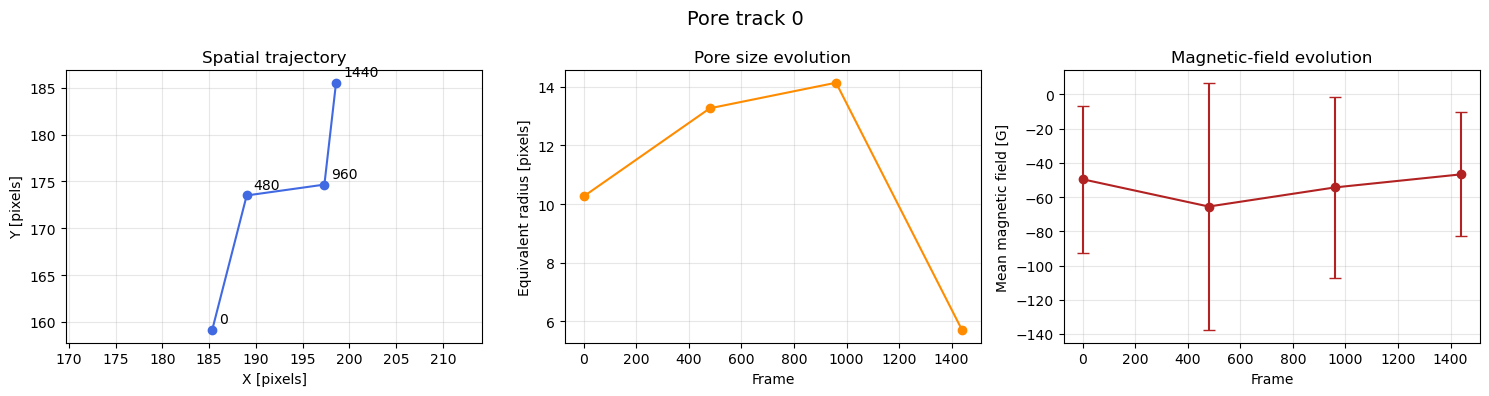

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spatial trajectory
axes[0].plot(x, y, "o-", color="royalblue")

for frame, xi, yi in zip(frames, x, y):
    axes[0].annotate(str(frame), (xi, yi), xytext=(5, 5),
                     textcoords="offset points")

axes[0].set_xlabel("X [pixels]")
axes[0].set_ylabel("Y [pixels]")
axes[0].set_title("Spatial trajectory")
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].grid(alpha=0.3)

# Equivalent radius evolution
axes[1].plot(frames, radii, "o-", color="darkorange")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Equivalent radius [pixels]")
axes[1].set_title("Pore size evolution")
axes[1].grid(alpha=0.3)

# Magnetic-field evolution
axes[2].errorbar(
    frames, B_mean, yerr=B_std,
    fmt="o-", capsize=4, color="firebrick"
)

axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Mean magnetic field [G]")
axes[2].set_title("Magnetic-field evolution")
axes[2].grid(alpha=0.3)

fig.suptitle(f"Pore track {track_id}", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Sort persistent pores by their mean magnetic field

sorted_persistent_pores = []

for track_id, history in persistent_pores.items():

    mean_B = np.mean([
        obs["mean_magnetic_field"]
        for obs in history
    ])

    sorted_persistent_pores.append({
        "track_id": track_id,
        "mean_magnetic_field": mean_B,
        "history": history
    })

# Sort by absolute mean magnetic field (descending order)
sorted_persistent_pores.sort(
    key=lambda pore: abs(pore["mean_magnetic_field"]),
    reverse=True
)
# Assign new IDs based on the magnetic-field ranking
for rank, pore in enumerate(sorted_persistent_pores, start=1):
    pore["original_track_id"] = pore["track_id"]
    pore["track_id"] = rank

In [38]:
for pore in sorted_persistent_pores:
    print(
        f'Pore {pore["track_id"]:02d} '
        f'(Original track {pore["original_track_id"]}): '
        f'<B> = {pore["mean_magnetic_field"]:+.2f} G'
    )

Pore 01 (Original track 60): <B> = -63.90 G
Pore 02 (Original track 35): <B> = -62.26 G
Pore 03 (Original track 81): <B> = +58.57 G
Pore 04 (Original track 11): <B> = +56.68 G
Pore 05 (Original track 57): <B> = +55.28 G
Pore 06 (Original track 0): <B> = -54.02 G
Pore 07 (Original track 27): <B> = -52.21 G
Pore 08 (Original track 12): <B> = -51.29 G
Pore 09 (Original track 101): <B> = +50.42 G
Pore 10 (Original track 93): <B> = +50.34 G
Pore 11 (Original track 54): <B> = -48.84 G
Pore 12 (Original track 4): <B> = -48.63 G
Pore 13 (Original track 23): <B> = +48.10 G
Pore 14 (Original track 33): <B> = -45.59 G
Pore 15 (Original track 63): <B> = -45.32 G
Pore 16 (Original track 98): <B> = -44.77 G
Pore 17 (Original track 18): <B> = +44.64 G
Pore 18 (Original track 52): <B> = -44.56 G
Pore 19 (Original track 31): <B> = -44.23 G
Pore 20 (Original track 79): <B> = -43.12 G
Pore 21 (Original track 44): <B> = -42.89 G
Pore 22 (Original track 7): <B> = -42.08 G
Pore 23 (Original track 87): <B> =

Pretty printing has been turned OFF


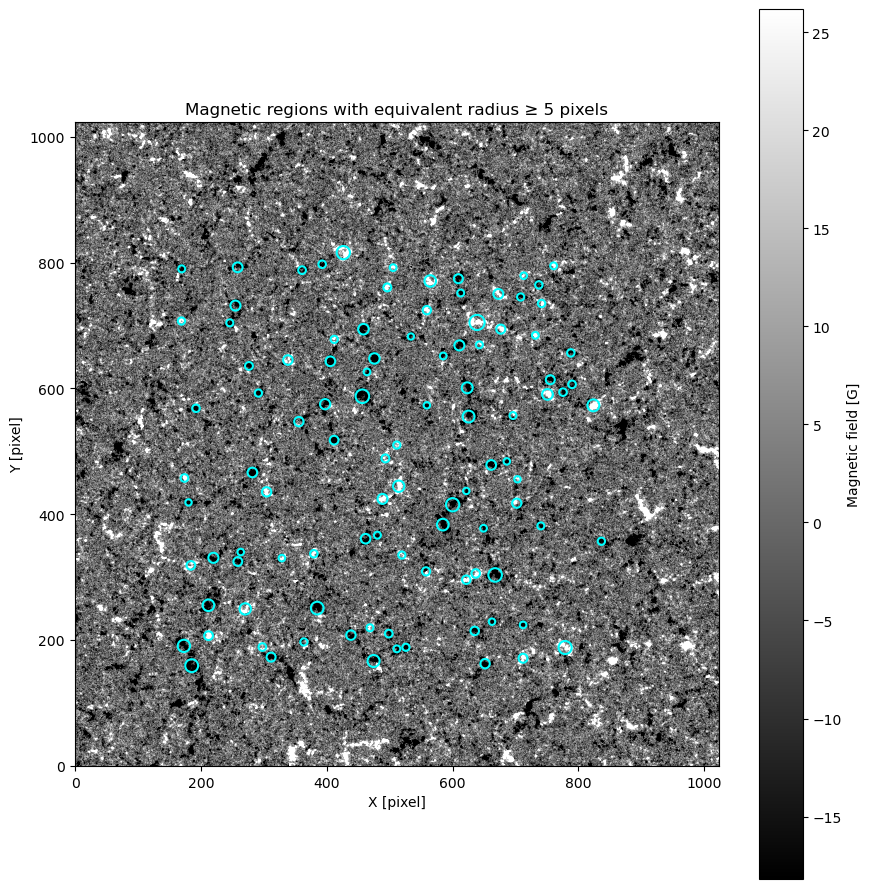

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# MAGNETOGRAMA + CÍRCULOS DE ÁREA EQUIVALENTE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Magnetograma
im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame,5),
    vmax=np.percentile(mag_frame,98)
)

# ------------------------------------------------------------
# Dibujar círculos de las regiones seleccionadas
# ------------------------------------------------------------

for region in selected_regions:

    circle = Circle(
        (region["x_center"], region["y_center"]),
        region["r_equivalent_pixels"],
        fill=False,
        linewidth=1.5,
        color='cyan'
    )

    ax.add_patch(circle)

# ------------------------------------------------------------
# Formato
# ------------------------------------------------------------

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    f"Magnetic regions with equivalent radius ≥ {min_radius} pixels"
)

plt.tight_layout()
plt.show()

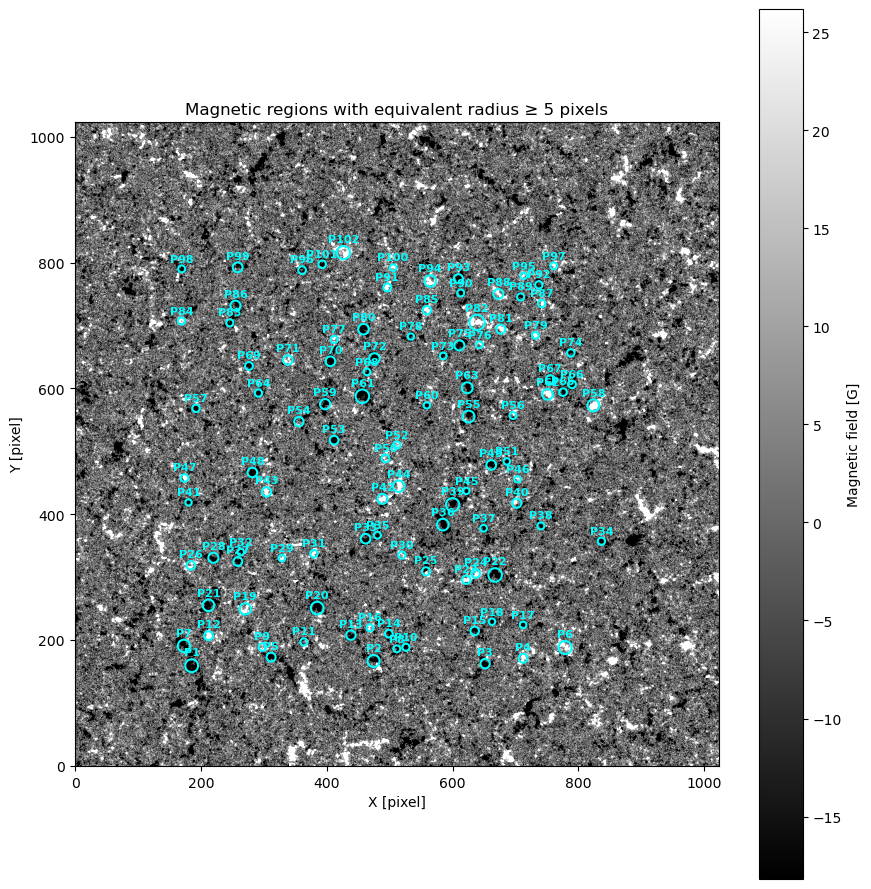

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# ============================================================
# ASIGNAR UN ID A CADA PORO
# ============================================================

for i, region in enumerate(selected_regions, start=1):
    region["pore_id"] = f"P{i}"


# ============================================================
# MAGNETOGRAMA + CÍRCULOS + IDs
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Magnetograma
im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame, 5),
    vmax=np.percentile(mag_frame, 98)
)


# ============================================================
# DIBUJAR CÍRCULOS E IDENTIFICADORES
# ============================================================

for region in selected_regions:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r  = region["r_equivalent_pixels"]

    # Círculo equivalente
    circle = Circle(
        (x0, y0),
        r,
        fill=False,
        linewidth=1.5,
        color="cyan"
    )

    ax.add_patch(circle)

    # Número/ID del poro
    ax.text(
        x0,
        y0 + r + 3,
        region["pore_id"],
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="cyan"
    )


# ============================================================
# FORMATO
# ============================================================

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    f"Magnetic regions with equivalent radius ≥ {min_radius} pixels"
)

plt.tight_layout()
plt.show()

## Chose the 5 strongest pores

In [8]:
# ============================================================
# CAMPO MAGNÉTICO MEDIO DENTRO DE CADA CÍRCULO
# ============================================================

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

for region in selected_regions:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r  = region["r_equivalent_pixels"]

    # Máscara circular
    circle_mask = (
        (xx - x0)**2 +
        (yy - y0)**2
        <= r**2
    )

    # Valores dentro del círculo
    values = mag_frame[circle_mask]

    # Campo absoluto medio
    region["mean_abs_B"] = np.nanmean(np.abs(values))


# ============================================================
# SELECCIONAR LOS 5 MÁS INTENSOS
# ============================================================

top10_pores = sorted(
    selected_regions,
    key=lambda region: region["mean_abs_B"],
    reverse=True
)[:10]


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("Top 10 pores by mean |B|:\n")

for region in top10_pores:

    print(
        f"{region['pore_id']}: "
        f"<|B|> = {region['mean_abs_B']:.2f} G, "
        f"center = ({region['x_center']:.2f}, "
        f"{region['y_center']:.2f}), "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )

Top 10 pores by mean |B|:

P72: <|B|> = 80.31 G, center = (475.81, 647.51), r_eq = 8.31 pix
P70: <|B|> = 78.41 G, center = (405.81, 642.99), r_eq = 7.69 pix
P58: <|B|> = 67.93 G, center = (823.85, 572.94), r_eq = 9.46 pix
P24: <|B|> = 65.70 G, center = (636.90, 305.74), r_eq = 6.77 pix
P3: <|B|> = 58.75 G, center = (651.71, 162.30), r_eq = 7.46 pix
P12: <|B|> = 58.10 G, center = (212.10, 206.81), r_eq = 6.98 pix
P5: <|B|> = 50.88 G, center = (311.53, 172.74), r_eq = 7.20 pix
P69: <|B|> = 50.71 G, center = (276.41, 635.59), r_eq = 6.26 pix
P44: <|B|> = 50.41 G, center = (514.42, 444.35), r_eq = 9.01 pix
P91: <|B|> = 47.80 G, center = (496.29, 760.42), r_eq = 6.28 pix


Selected pores:
P72: <|B|> = 80.31 G, r_eq = 8.31 pix
P70: <|B|> = 78.41 G, r_eq = 7.69 pix
P58: <|B|> = 67.93 G, r_eq = 9.46 pix
P24: <|B|> = 65.70 G, r_eq = 6.77 pix
P3: <|B|> = 58.75 G, r_eq = 7.46 pix
P12: <|B|> = 58.10 G, r_eq = 6.98 pix
P5: <|B|> = 50.88 G, r_eq = 7.20 pix
P69: <|B|> = 50.71 G, r_eq = 6.26 pix
P44: <|B|> = 50.41 G, r_eq = 9.01 pix
P91: <|B|> = 47.80 G, r_eq = 6.28 pix


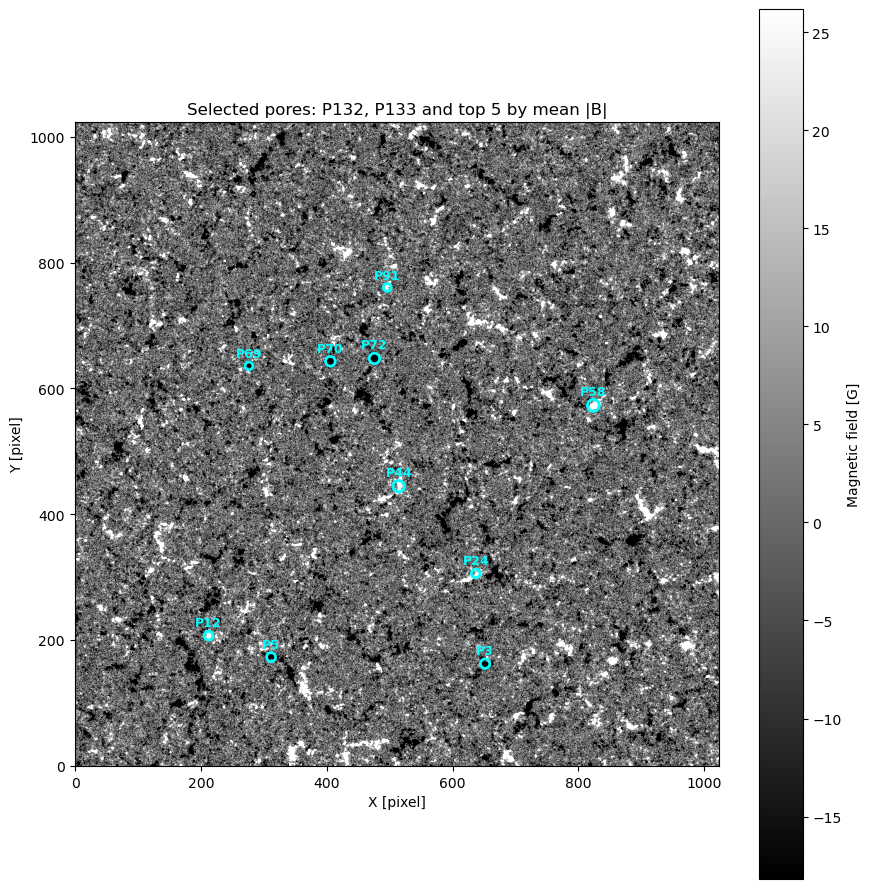

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# ============================================================
# 1. SELECCIONAR P132 Y P133
# ============================================================

manual_ids = ["P132", "P133"]

manual_pores = [
    region for region in selected_regions
    if region["pore_id"] in manual_ids
]


# ============================================================
# 2. COMBINAR CON LOS 5 POROS MÁS FUERTES
# ============================================================

pores_to_plot = top10_pores + manual_pores

# Evitar duplicados por si P132 o P133 ya está en el top 5
pores_to_plot = list({
    region["pore_id"]: region
    for region in pores_to_plot
}.values())

print("Selected pores:")
for region in pores_to_plot:
    print(
        f"{region['pore_id']}: "
        f"<|B|> = {region['mean_abs_B']:.2f} G, "
        f"r_eq = {region['r_equivalent_pixels']:.2f} pix"
    )


# ============================================================
# 3. GRAFICAR MAGNETOGRAMA
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

im = ax.imshow(
    mag_frame,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(mag_frame, 5),
    vmax=np.percentile(mag_frame, 98)
)


# ============================================================
# 4. GRAFICAR LOS POROS SELECCIONADOS
# ============================================================

for region in pores_to_plot:

    x0 = region["x_center"]
    y0 = region["y_center"]
    r = region["r_equivalent_pixels"]

    circle = Circle(
        (x0, y0),
        r,
        fill=False,
        linewidth=2,
        color="cyan"
    )

    ax.add_patch(circle)

    ax.text(
        x0,
        y0 + r + 3,
        region["pore_id"],
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="cyan"
    )


# ============================================================
# 5. FORMATO
# ============================================================

plt.colorbar(
    im,
    ax=ax,
    label="Magnetic field [G]"
)

ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

ax.set_title(
    "Selected pores: P132, P133 and top 5 by mean |B|"
)

plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np

# ============================================================
# GUARDAR LOS POROS SELECCIONADOS (pores_to_plot) EN UN .npz
# ============================================================
# Geometría definida en el primer frame (t = 0). El archivo se
# puede reutilizar para construir máscaras o dibujar los poros
# sobre cualquier otro mapa con la misma geometría (1024 x 1024).

pores_npz = "../data/2018_08_25/pores/selected_pores_MAG_24_frame0.npz"
os.makedirs(os.path.dirname(pores_npz), exist_ok=True)

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

n_sel = len(pores_to_plot)

circle_masks   = np.zeros((n_sel, ny, nx), dtype=bool)   # círculo de radio equivalente
region_masks   = np.zeros((n_sel, ny, nx), dtype=bool)   # región conexa exacta (|B| > p80)
pore_label_map = np.zeros((ny, nx), dtype=np.int16)      # 0 = fondo, k = poro k (1..n)

for k, region in enumerate(pores_to_plot):

    circle = (
        (xx - region["x_center"])**2 +
        (yy - region["y_center"])**2
        <= region["r_equivalent_pixels"]**2
    )

    circle_masks[k] = circle
    region_masks[k] = labeled_regions == region["label"]

    # Si dos círculos se solapan, conserva el primero que ocupó el píxel
    pore_label_map[circle & (pore_label_map == 0)] = k + 1

np.savez_compressed(
    pores_npz,
    # --- identificación ---
    pore_id        = np.array([r["pore_id"] for r in pores_to_plot]),
    region_label   = np.array([r["label"] for r in pores_to_plot], dtype=np.int32),
    is_manual      = np.array([r["pore_id"] in manual_ids for r in pores_to_plot]),
    # --- geometría (píxeles, origen en el píxel [0, 0]) ---
    x_center       = np.array([r["x_center"] for r in pores_to_plot], dtype=np.float64),
    y_center       = np.array([r["y_center"] for r in pores_to_plot], dtype=np.float64),
    r_eq           = np.array([r["r_equivalent_pixels"] for r in pores_to_plot], dtype=np.float64),
    area_pixels    = np.array([r["area_pixels"] for r in pores_to_plot], dtype=np.int32),
    mean_abs_B     = np.array([r["mean_abs_B"] for r in pores_to_plot], dtype=np.float64),
    # --- máscaras ---
    circle_masks   = circle_masks,
    region_masks   = region_masks,
    pore_label_map = pore_label_map,
    # --- metadatos ---
    threshold_p80  = np.float64(p80),
    frame_index    = np.int32(0),
    frame_shape    = np.array([ny, nx], dtype=np.int32),
    source_cube    = np.array(MAG_cube),
    fits_header    = np.array(header.tostring(sep="\n")),
)

print(f"Guardados {n_sel} poros en: {pores_npz}")
for r in pores_to_plot:
    print(f"  {r['pore_id']:>5s}  center = ({r['x_center']:.2f}, {r['y_center']:.2f})  "
          f"r_eq = {r['r_equivalent_pixels']:.2f} pix  <|B|> = {r['mean_abs_B']:.2f} G")

Guardados 10 poros en: ../data/2018_08_25/pores/selected_pores_MAG_24_frame0.npz
    P72  center = (475.81, 647.51)  r_eq = 8.31 pix  <|B|> = 80.31 G
    P70  center = (405.81, 642.99)  r_eq = 7.69 pix  <|B|> = 78.41 G
    P58  center = (823.85, 572.94)  r_eq = 9.46 pix  <|B|> = 67.93 G
    P24  center = (636.90, 305.74)  r_eq = 6.77 pix  <|B|> = 65.70 G
     P3  center = (651.71, 162.30)  r_eq = 7.46 pix  <|B|> = 58.75 G
    P12  center = (212.10, 206.81)  r_eq = 6.98 pix  <|B|> = 58.10 G
     P5  center = (311.53, 172.74)  r_eq = 7.20 pix  <|B|> = 50.88 G
    P69  center = (276.41, 635.59)  r_eq = 6.26 pix  <|B|> = 50.71 G
    P44  center = (514.42, 444.35)  r_eq = 9.01 pix  <|B|> = 50.41 G
    P91  center = (496.29, 760.42)  r_eq = 6.28 pix  <|B|> = 47.80 G


 [astropy.io.fits.verify]


Cube shape: (1920, 1024, 1024) | dtype: >i8 | BSCALE: 1e-16 | BZERO: 0.0 | BLANK: None
Máx. diferencia frame 0 vs mag_frame [G]: 0.0
Processed 200/1920 frames (10.4%)
Processed 400/1920 frames (20.8%)
Processed 600/1920 frames (31.2%)
Processed 800/1920 frames (41.7%)
Processed 1000/1920 frames (52.1%)
Processed 1200/1920 frames (62.5%)
Processed 1400/1920 frames (72.9%)
Processed 1600/1920 frames (83.3%)
Processed 1800/1920 frames (93.8%)
Processed 1920/1920 frames (100.0%)

Umbral |B| > 13.19 G  |  presencia si f_t >= 50%


,Pore,x_center,y_center,r_eq (pix),Valid frames,Frames present,Persistence (%),Area > thr (%),|B|-weighted area (%),<|B|> t0 (G),<|B|> day (G),<|B|> above thr (G),Intensity index (G),Score (%)
0,P58,823.85,572.94,9.46,1920,1064,55.42,44.44,75.05,67.93,33.08,50.18,30.28,100.00
1,P44,514.42,444.35,9.01,1920,440,22.92,42.46,84.50,50.41,23.50,42.68,20.53,67.81
2,P72,475.81,647.51,8.31,1920,459,23.91,30.97,61.92,80.31,21.78,36.91,18.29,60.41
3,P3,651.71,162.30,7.46,1920,447,23.28,32.91,68.19,58.75,21.61,40.10,18.21,60.16
4,P12,212.10,206.81,6.98,1920,296,15.42,31.19,68.50,58.10,18.78,37.34,15.29,50.51
5,P24,636.90,305.74,6.77,1920,628,32.71,39.40,76.05,65.70,18.13,32.06,14.99,49.50
6,P70,405.81,642.99,7.69,1920,414,21.56,28.21,57.12,78.41,18.40,32.69,14.79,48.86
7,P69,276.41,635.59,6.26,1920,435,22.66,30.03,62.03,50.71,15.99,30.19,12.44,41.09
8,P5,311.53,172.74,7.20,1920,288,15.00,27.56,61.14,50.88,14.28,28.95,10.62,35.08
9,P91,496.29,760.42,6.28,1920,167,8.70,23.22,52.51,47.80,10.55,21.89,6.65,21.97


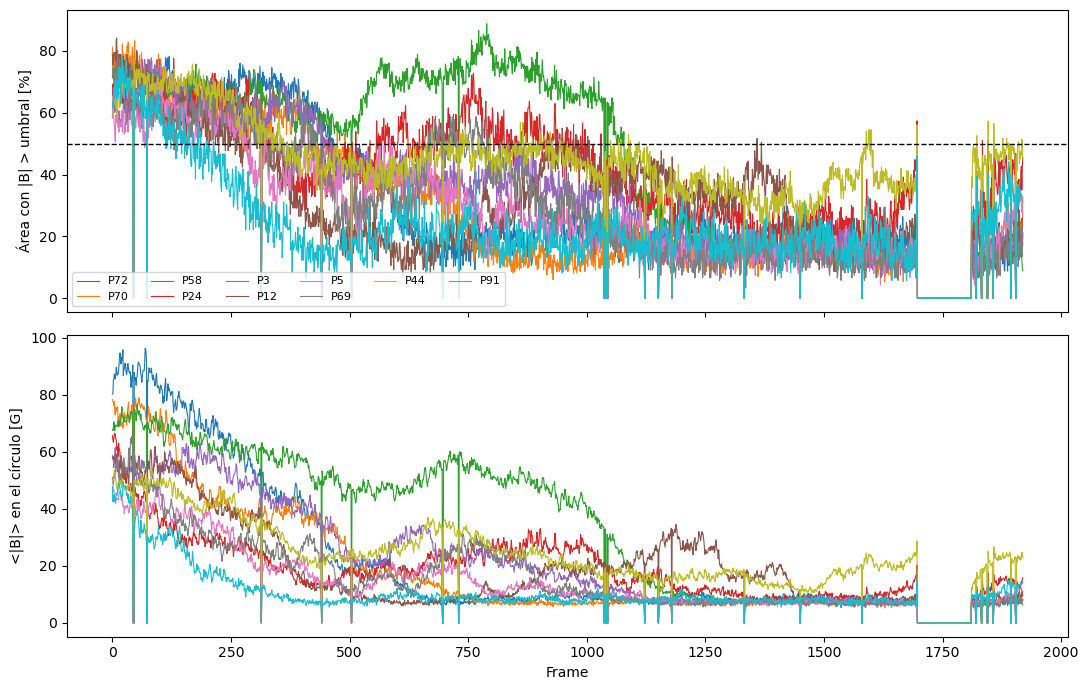

In [11]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"

# ============================================================
# 1. PARÁMETROS
# ============================================================

pores_to_study = pores_to_plot

# Umbral de referencia: p80 de |B| en el primer frame (en Gauss)
B_threshold = p80

# Un poro está "presente" en un frame si al menos esta fracción
# de los píxeles de su círculo supera el umbral
presence_fraction_threshold = 0.50

# Un frame solo cuenta para un poro si al menos esta fracción
# de sus píxeles es finita (evita frames vacíos / NaN)
min_finite_fraction = 0.90

n_pores = len(pores_to_study)


# ============================================================
# 2. ABRIR EL CUBO (memmap, sin escalar todo el cubo)
# ============================================================
# IMPORTANTE: con do_not_scale_image_data=True los datos vienen
# en unidades "crudas". Hay que aplicar  B = raw * BSCALE + BZERO
# para que sean comparables con p80 (que está en Gauss).
# En la versión anterior esto no se hacía (BSCALE = 1e-16), así que
# TODOS los píxeles superaban el umbral y todos los poros daban
# el mismo porcentaje (solo cambiaban los frames con NaN).

with fits.open(MAG_cube, memmap=True, do_not_scale_image_data=True) as hdul:

    cube_raw = hdul[0].data
    hdr      = hdul[0].header

    bscale = hdr.get("BSCALE", 1.0)
    bzero  = hdr.get("BZERO", 0.0)
    blank  = hdr.get("BLANK", None) if np.issubdtype(cube_raw.dtype, np.integer) else None

    n_frames, ny, nx = cube_raw.shape
    print("Cube shape:", cube_raw.shape, "| dtype:", cube_raw.dtype,
          "| BSCALE:", bscale, "| BZERO:", bzero, "| BLANK:", blank)

    # ========================================================
    # 3. PÍXELES DE CADA PORO (fijos, definidos en el frame 0)
    # ========================================================
    # Se concatenan todos los píxeles de los 12 poros en un solo
    # vector para leer cada frame con un único acceso al memmap.

    all_y, all_x, owner = [], [], []

    for i, region in enumerate(pores_to_study):

        x0, y0, r = region["x_center"], region["y_center"], region["r_equivalent_pixels"]

        x_min = max(0, int(np.floor(x0 - r)));  x_max = min(nx, int(np.ceil(x0 + r)) + 1)
        y_min = max(0, int(np.floor(y0 - r)));  y_max = min(ny, int(np.ceil(y0 + r)) + 1)

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        circle = (xx - x0)**2 + (yy - y0)**2 <= r**2

        all_y.append(yy[circle])
        all_x.append(xx[circle])
        owner.append(np.full(circle.sum(), i))

    all_y = np.concatenate(all_y)
    all_x = np.concatenate(all_x)
    owner = np.concatenate(owner)

    n_pix = np.bincount(owner, minlength=n_pores)

    # Chequeo: el frame 0 escalado debe coincidir con mag_frame
    check = cube_raw[0, all_y, all_x].astype(np.float64) * bscale + bzero
    ref   = mag_frame[all_y, all_x].astype(np.float64)
    ok    = np.isfinite(check) & np.isfinite(ref)
    print("Máx. diferencia frame 0 vs mag_frame [G]:",
          np.max(np.abs(check[ok] - ref[ok])) if ok.any() else "sin datos")

    # ========================================================
    # 4. SERIES TEMPORALES POR PORO
    # ========================================================

    area_fraction   = np.full((n_pores, n_frames), np.nan)  # f_t   : fracción de píxeles con |B| > umbral
    flux_fraction   = np.full((n_pores, n_frames), np.nan)  # fw_t  : fracción de Σ|B| aportada por esos píxeles
    mean_absB       = np.full((n_pores, n_frames), np.nan)  # <|B|> en el círculo [G]
    mean_absB_above = np.full((n_pores, n_frames), np.nan)  # <|B|> solo de píxeles sobre el umbral [G]
    flux_density    = np.full((n_pores, n_frames), np.nan)  # Σ|B|·H(|B|-umbral) / N_pix  [G]

    for t in range(n_frames):

        raw  = cube_raw[t, all_y, all_x]
        vals = raw.astype(np.float64)

        if blank is not None:
            vals[raw == blank] = np.nan

        absB   = np.abs(vals * bscale + bzero)
        finite = np.isfinite(absB)
        above  = finite & (absB > B_threshold)
        absB0  = np.where(finite, absB, 0.0)

        n_fin     = np.bincount(owner, weights=finite,        minlength=n_pores)
        n_above   = np.bincount(owner, weights=above,         minlength=n_pores)
        sum_B     = np.bincount(owner, weights=absB0,         minlength=n_pores)
        sum_Babov = np.bincount(owner, weights=absB0 * above, minlength=n_pores)

        valid = n_fin >= min_finite_fraction * n_pix

        with np.errstate(invalid="ignore", divide="ignore"):
            area_fraction[valid, t]   = (n_above   / n_fin)[valid]
            flux_fraction[valid, t]   = (sum_Babov / sum_B)[valid]
            mean_absB[valid, t]       = (sum_B     / n_fin)[valid]
            mean_absB_above[valid, t] = np.where(n_above > 0, sum_Babov / n_above, 0.0)[valid]
            flux_density[valid, t]    = (sum_Babov / n_fin)[valid]

        if (t + 1) % 200 == 0 or t == n_frames - 1:
            print(f"Processed {t + 1}/{n_frames} frames ({100*(t+1)/n_frames:.1f}%)")


# ============================================================
# 5. MÉTRICAS DE PERSISTENCIA
# ============================================================
#  - Persistence (%)          : % de frames válidos con f_t >= 50 %
#  - Area > thr (%)           : promedio temporal de f_t
#  - |B|-weighted area > thr  : promedio temporal de fw_t
#                               (cada píxel pesa según su |B|)
#  - Intensity index [G]      : promedio temporal de Σ|B|·H(|B|-thr)/N_pix
#                               -> combina ÁREA sobre el umbral e INTENSIDAD
#  - Score (%)                : Intensity index normalizado al mejor poro
#                               (criterio de ordenamiento final)

valid_frames = np.isfinite(area_fraction)
presence     = (area_fraction >= presence_fraction_threshold) & valid_frames

results = []

for i, region in enumerate(pores_to_study):

    v  = valid_frames[i]
    nv = v.sum()

    results.append({
        "Pore":                    region["pore_id"],
        "x_center":                region["x_center"],
        "y_center":                region["y_center"],
        "r_eq (pix)":              region["r_equivalent_pixels"],
        "Valid frames":            int(nv),
        "Frames present":          int(presence[i].sum()),
        "Persistence (%)":         100 * presence[i].sum() / nv if nv else np.nan,
        "Area > thr (%)":          100 * np.nanmean(area_fraction[i]),
        "|B|-weighted area (%)":   100 * np.nanmean(flux_fraction[i]),
        "<|B|> t0 (G)":            region["mean_abs_B"],
        "<|B|> day (G)":           np.nanmean(mean_absB[i]),
        "<|B|> above thr (G)":     np.nanmean(mean_absB_above[i]),
        "Intensity index (G)":     np.nanmean(flux_density[i]),
    })

persistence_df = pd.DataFrame(results)
persistence_df["Score (%)"] = (
    100 * persistence_df["Intensity index (G)"] / persistence_df["Intensity index (G)"].max()
)

persistence_df = persistence_df.sort_values("Score (%)", ascending=False).reset_index(drop=True)

print(f"\nUmbral |B| > {B_threshold:.2f} G  |  presencia si f_t >= {presence_fraction_threshold:.0%}")

# Opcional: guardar la tabla
# persistence_df.to_csv("../data/2018_08_25/pores/pores_persistence_MAG_24.csv", index=False)

display(persistence_df.round(2))


# ============================================================
# 6. CONTROL VISUAL: FRACCIÓN SOBRE EL UMBRAL VS TIEMPO
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for i, region in enumerate(pores_to_study):
    axes[0].plot(100 * area_fraction[i], lw=0.8, label=region["pore_id"])
    axes[1].plot(mean_absB[i],           lw=0.8, label=region["pore_id"])

axes[0].axhline(100 * presence_fraction_threshold, color="k", ls="--", lw=1)
axes[0].set_ylabel("Área con |B| > umbral [%]")
axes[1].set_ylabel("<|B|> en el círculo [G]")
axes[1].set_xlabel("Frame")
axes[0].legend(ncol=6, fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

In [12]:
import os
import numpy as np

# ============================================================
# REGIONES ORDENADAS POR SCORE -> R01, R02, ... + GUARDAR .npz
# ============================================================
# Requiere haber corrido la celda de persistencia
# (persistence_df, pores_to_study, mean_absB, area_fraction, ...)

ranked_npz = "../data/2018_08_25/pores/ranked_regions_MAG_24.npz"
os.makedirs(os.path.dirname(ranked_npz), exist_ok=True)

# ------------------------------------------------------------
# 1. ORDEN POR SCORE Y NUEVOS NOMBRES
# ------------------------------------------------------------

ranked_df = persistence_df.sort_values("Score (%)", ascending=False).reset_index(drop=True)

id_to_idx = {r["pore_id"]: i for i, r in enumerate(pores_to_study)}
order     = np.array([id_to_idx[p] for p in ranked_df["Pore"]])   # índice original de cada rank

n_reg      = len(order)
rank_names = np.array([f"R{k+1:02d}" for k in range(n_reg)])      # R01 = mejor score
ranked_df.insert(0, "Region", rank_names)
ranked_df.insert(1, "Rank", np.arange(1, n_reg + 1))

# ------------------------------------------------------------
# 2. MÁSCARAS EN EL ORDEN DEL RANKING
# ------------------------------------------------------------

ny, nx = mag_frame.shape
yy, xx = np.mgrid[0:ny, 0:nx]

circle_masks   = np.zeros((n_reg, ny, nx), dtype=bool)
region_masks   = np.zeros((n_reg, ny, nx), dtype=bool)
rank_label_map = np.zeros((ny, nx), dtype=np.int16)   # 0 = fondo, k = región R{k}

for k, i in enumerate(order):
    reg = pores_to_study[i]
    circ = (xx - reg["x_center"])**2 + (yy - reg["y_center"])**2 <= reg["r_equivalent_pixels"]**2
    circle_masks[k] = circ
    region_masks[k] = labeled_regions == reg["label"]
    rank_label_map[circ & (rank_label_map == 0)] = k + 1

# ------------------------------------------------------------
# 3. CAMPO MAGNÉTICO MEDIO (recompilado)
# ------------------------------------------------------------

B_t0_signed = np.array([np.nanmean(mag_frame[circle_masks[k]])         for k in range(n_reg)])
B_t0_abs    = np.array([np.nanmean(np.abs(mag_frame[circle_masks[k]])) for k in range(n_reg)])

absB_series = mean_absB[order]                       # (n_reg, n_frames) <|B|>(t) de cada región
B_day_abs   = np.nanmean(absB_series, axis=1)        # <|B|> promedio del día
B_day_std   = np.nanstd(absB_series, axis=1)         # variabilidad temporal
B_day_med   = np.nanmedian(absB_series, axis=1)

polarity = np.sign(B_t0_signed).astype(np.int8)      # +1 / -1

# Orden por intensidad magnética (de mayor a menor <|B|> del día),
# expresado como índices sobre el arreglo ya ordenado por score
order_by_B = np.argsort(-B_day_abs)

ranked_df["<B> t0 signed (G)"] = B_t0_signed
ranked_df["<|B|> t0 (G)"]      = B_t0_abs
ranked_df["<|B|> day (G)"]     = B_day_abs
ranked_df["std |B| day (G)"]   = B_day_std
ranked_df["Polarity"]          = polarity
ranked_df["Rank by |B|"]       = np.argsort(order_by_B) + 1

# ------------------------------------------------------------
# 4. GUARDAR
# ------------------------------------------------------------

np.savez_compressed(
    ranked_npz,
    # identificación (todo en orden de score: índice 0 = R01)
    region_name        = rank_names,
    rank               = np.arange(1, n_reg + 1, dtype=np.int32),
    original_pore_id   = ranked_df["Pore"].to_numpy().astype(str),
    # geometría
    x_center           = ranked_df["x_center"].to_numpy(float),
    y_center           = ranked_df["y_center"].to_numpy(float),
    r_eq               = ranked_df["r_eq (pix)"].to_numpy(float),
    circle_masks       = circle_masks,
    region_masks       = region_masks,
    rank_label_map     = rank_label_map,
    # campo magnético
    B_t0_signed        = B_t0_signed,
    B_t0_abs           = B_t0_abs,
    B_day_abs          = B_day_abs,
    B_day_std          = B_day_std,
    B_day_median       = B_day_med,
    polarity           = polarity,
    absB_series        = absB_series.astype(np.float32),
    area_fraction_series = (area_fraction[order]).astype(np.float32),
    order_by_B         = order_by_B.astype(np.int32),
    # persistencia
    score              = ranked_df["Score (%)"].to_numpy(float),
    intensity_index    = ranked_df["Intensity index (G)"].to_numpy(float),
    persistence        = ranked_df["Persistence (%)"].to_numpy(float),
    area_above_thr     = ranked_df["Area > thr (%)"].to_numpy(float),
    # metadatos
    threshold_B        = np.float64(B_threshold),
    frame_shape        = np.array([ny, nx], dtype=np.int32),
    source_cube        = np.array(MAG_cube),
)

print(f"Guardado: {ranked_npz}\n")
display(ranked_df[["Region", "Pore", "Score (%)", "Persistence (%)",
                   "<|B|> day (G)", "std |B| day (G)", "<B> t0 signed (G)",
                   "Polarity", "Rank by |B|"]].round(2))

Guardado: ../data/2018_08_25/pores/ranked_regions_MAG_24.npz



,Region,Pore,Score (%),Persistence (%),<|B|> day (G),std |B| day (G),<B> t0 signed (G),Polarity,Rank by |B|
0,R01,P58,100.00,55.42,33.08,24.57,65.61,1,1
1,R02,P44,67.81,22.92,23.50,12.02,48.83,1,2
2,R03,P72,60.41,23.91,21.78,25.38,-78.82,-1,3
3,R04,P3,60.16,23.28,21.61,17.92,-57.63,-1,4
4,R05,P12,50.51,15.42,18.78,15.10,57.09,1,5
5,R06,P24,49.50,32.71,18.13,11.02,64.85,1,7
6,R07,P70,48.86,21.56,18.40,19.72,-77.54,-1,6
7,R08,P69,41.09,22.66,15.99,12.86,-50.43,-1,8
8,R09,P5,35.08,15.00,14.28,11.02,-49.49,-1,9
9,R10,P91,21.97,8.70,10.55,8.18,46.84,1,10
